In [1]:
%%bash
hostname

node893.cluster


In [2]:
%%bash
nvidia-smi

Fri Mar 14 10:47:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                Off |   00000000:05:00.0 Off |                    0 |
| N/A   46C    P0             64W /  350W |       1MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft
from IPython.display import Latex
import scipy.signal

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom12_ics_v1/output', 247, basename='snap')
# snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom8/output',
#                    305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([5e2, 5e2, 5e2], dtype=float) ## good for testing
# widths = np.array([2e1, 2e1, 2e1], dtype=float)



In [4]:
print(cp.cuda.runtime.getDeviceCount())

1


In [5]:
# cp.cuda.Device(2).use()

In [6]:
import cmasher as cmr
get_ipython().run_line_magic('matplotlib', 'widget')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

grays = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))
blues = plt.cm.Blues_r(np.linspace(0,1,10))
greens = plt.cm.Greens_r(np.linspace(0,1,10))
oranges = plt.cm.Oranges_r(np.linspace(0,1,10))

# plt.rc('font', family='serif')
# plt.rcParams['font.serif'] = 'ITC Bookman'
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 16
plt.rcParams['ytick.labelsize']= 16
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'


In [7]:
arepo_length = snap['0_Coordinates'].uq
density_unit = snap['0_Density'].uq
kpc = snap.uq('kpc')

filter_length_max = (widths[0]/5)*np.ones(snap['0_Diameters'].shape)*arepo_length

mhat = tc.MexicanHatPowerSpectrum(snap, center, widths, npix=256, orientation=None, 
                        search_radius=filter_length_max.value)

Attempting to get derived variable: 0_Diameters...
	So we need the variable: 0_Volume...	[DONE]



In [8]:

def enforce_hermitian(amplitude_matrix):
    ## this is for odd matrices
    amplitudes = amplitude_matrix.copy()
    Nx, Ny, Nz = amplitudes.shape
    for kk in range(0,Nz//2):
        amplitudes[:,:,kk]=np.conj(np.flip(amplitudes)[:,:,kk])
    
    amplitudes[:Nx//2+1,:Ny//2+1,Nz//2]=np.conj(np.flip(amplitudes)[:Nx//2+1,:Ny//2+1,Nz//2])
    amplitudes[:Nx//2+1,Ny//2+1:,Nz//2]=np.conj(np.flip(amplitudes)[:Nx//2+1,Ny//2+1:,Nz//2])
    amplitudes[Nx//2+1:,Ny//2+1:,Nz//2]=np.conj(np.flip(amplitudes)[Nx//2+1:,Ny//2+1:,Nz//2])
    amplitudes[Nx//2+1:,:Ny//2+1,Nz//2]=np.conj(np.flip(amplitudes)[Nx//2+1:,:Ny//2+1,Nz//2])

    return amplitudes

In [9]:
def P1d(FFTw, K2, widths):

    # FFTw and K2 have the same shape:
    # (Nx,Ny,Nz) (for complex transform)

    Nx, Ny, Nz = FFTw.shape
    Lx, Ly, Lz = widths

    kxmax = (2.0*np.pi/Lx)*(Nx//2)
    kymax = (2.0*np.pi/Ly)*(Ny//2)
    kzmax = (2.0*np.pi/Lz)*(Nz//2)


    kmax = np.sqrt(kxmax**2 + kymax**2 + kzmax**2)
    kmin = 0
    nbin = int(kmax/(2.0*np.pi/np.min(widths) ) + 0.5)
    deltak = 2.0*np.pi/np.min(widths)

    spectrum_1d = np.zeros(nbin)
    wavevec = np.arange(nbin)*deltak

    for i in range(Nx):
        for j in range(Ny):
            for k in range(Nz):

                m = int( np.floor( pow( K2[i,j,k], 0.5 ) / (deltak) + 0.5 ) )
                if (m < nbin):
                    spectrum_1d[m] += np.real( FFTw[ i,j,k] * np.conj( FFTw[i,j,k] ) ) / (Nx*Ny*Nz)**2

    spectrum_1d *= (2.*np.pi/deltak)*(Lx*Ly*Lz)

    energy_fourier_space = np.sum(spectrum_1d*deltak/(2.0*np.pi))
    print('energy (fourier space) = %.4e'%(energy_fourier_space))
    return spectrum_1d, wavevec

In [10]:
def gaussian_profile(x,y,z,sigma):
    return np.exp(-0.5*(x**2+y**2+z**2)/sigma**2)/(np.sqrt(2.*np.pi)*sigma)**3

In [11]:
widths_slicer = widths.copy()
widths_slicer[2] = 0.
center_slicer = center.copy
slicer = pa.Slicer(snap, center_slicer, widths_slicer, 'z', npix=2048)
extent = slicer.centered_extent.to('Mpc')

In [12]:

# ## generate Kolmogorov IC
nmax = 33
nfreq_tot = nmax**3
sigma = 100
rng = np.random.default_rng(seed=456789)

x = snap['0_Coordinates'][mhat.index][:, 0].value - center[0].value
y = snap['0_Coordinates'][mhat.index][:, 1].value - center[1].value
z = snap['0_Coordinates'][mhat.index][:, 2].value - center[2].value

kx_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[0])
ky_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[1])
kz_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[2])

KX, KY, KZ = np.meshgrid(kx_vec, ky_vec, kz_vec, sparse=False, indexing='ij')

K2 = KX**2 + KY**2 + KZ**2 
phases_rho = 2.0*np.pi*rng.uniform(low=-1.0, high=1.0, size=(nmax,nmax,nmax))
phases_rho[K2==0] = 0.0

phases_center = 0.5*(KX*widths[0] + KY*widths[1] + KZ*widths[2])

K2min = (2.0*np.pi/widths[0])**2 + (2.0*np.pi/widths[1])**2 + (2.0*np.pi/widths[2])**2
# K2min *= 9
power_law_exponent = -5./3.
# energy per 3D mode \times k^2 = E(k) \sim k^power_law_exponent
# ==> energy per 3D mode \sim k^[(power_law_exponent-2)/2]
ampl = np.zeros(K2.shape)
ampl = np.where(K2>3*K2min,1e-3*np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)
ampl = np.where(K2==0,1.0,ampl)

amplitudes_rho_fluct = nfreq_tot*ampl*np.exp(1j*phases_rho)*np.exp(1j*phases_center)
# amplitudes_rho_fluct *= np.exp(1j*0.5*(KX*widths[0] + KY*widths[1] + KZ*widths[2]))
amplitudes_rho_fluct = enforce_hermitian(amplitudes_rho_fluct)


amplitudes_rho_backgr = nfreq_tot*np.exp(-0.5*K2*sigma**2)*np.exp(1j*0.0)  
# *np.exp(1j*phases_center)  

fluct_rhofield = np.zeros(snap['0_Density'].shape)
background_rhofield = np.zeros(snap['0_Density'].shape)

## redo this with finufft 
fluct_rhofield[mhat.index] = np.real(finufft.nufft3d2(((2.0*np.pi/widths[0])*x)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[1])*y)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[2])*z)%(2.*np.pi), 
                             amplitudes_rho_fluct/(nfreq_tot)   , eps=1e-10, isign=-1))
                             
background_rhofield[mhat.index] = np.real(finufft.nufft3d2(((2.0*np.pi/widths[0])*x)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[1])*y)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[2])*z)%(2.*np.pi), 
                             amplitudes_rho_backgr/(nfreq_tot)   , eps=1e-10, isign=-1))


snap['0_synthetic_rhofield'] = background_rhofield * (fluct_rhofield) * density_unit
snap['0_synthetic_backg'] = background_rhofield * density_unit
snap['0_synthetic_fluct'] = (fluct_rhofield - 1.0) * density_unit
# snap['0_synthetic_rhofield'] = background_rhofield * (1.0) * density_unit


/tmp/ipykernel_153998/1154963644.py:29: RuntimeWarning: divide by zero encountered in power
  ampl = np.where(K2>3*K2min,1e-3*np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)


In [13]:
fluct_rhofield[mhat.index].min()

0.9688080466044328

In [14]:
background_rhofield[mhat.index].max()

7.936728862268981

In [15]:
import scipy.ndimage

In [16]:
amplitudes_rho_tot = scipy.ndimage.convolve(amplitudes_rho_backgr,
                                            amplitudes_rho_fluct,
                                            mode='constant',
                                            cval=0.0,
                                           origin=0)

amplitudes_rho_tot /= nfreq_tot

In [17]:
amplitudes_rho_tot[16,16,17]

(16316.627227815616+0.03034790078002925j)

In [18]:
## prepare deposit class
ngrid = 64

with tc.DepositCartesianGrid(snap, center, widths, npoints=ngrid, 
                           threadsperblock=256, 
                           regionType='cartesian', kernel_type="PCS") as depo:

    ## deposit density to cartesian grid
    density_total = depo.deposit_variable('0_synthetic_rhofield', weight='0_Volume')
    density_backg = depo.deposit_variable('0_synthetic_backg', weight='0_Volume')
    density_fluct = depo.deposit_variable('0_synthetic_fluct', weight='0_Volume')
    
    ## different usages of power_spectrum1d method
    
    # basic 
    powerspectr_basic, k1d_basic, (KX_basic, KY_basic, KZ_basic, hat_var_basic) = depo.power_spectrum1d(density_total)
    # basic background
    powerspectr_backg_basic, k1d_basic, (KX_basic, KY_basic, KZ_basic, hat_var_basic) = depo.power_spectrum1d(density_backg)
    
    # with zero-padding
    powerspectr_padded, k1d_padded, (KX_padded, KY_padded, KZ_padded, hat_var_padded) = depo.power_spectrum1d(density_total,
                                                              npads=2)
    
    # with windowing
    powerspectr_hann, k1d_hann, (KX_hann, KY_hann, KZ_hann, hat_var_hann) = depo.power_spectrum1d(density_total,
                                                              window=scipy.signal.windows.hann)
    
    powerspectr_fluct_hann, _, _ = depo.power_spectrum1d(density_fluct,
                                                              window=scipy.signal.windows.hann)
    
    powerspectr_backg_hann, _, _ = depo.power_spectrum1d(density_backg,
                                                              window=scipy.signal.windows.hann)

energy (real space) = 3.5797e+08
energy (fourier space) = 3.5797e+08
energy (real space) = 3.5790e+08
energy (fourier space) = 3.5790e+08
energy (real space) = 3.5797e+08
energy (fourier space) = 3.5797e+08
energy (real space) = 3.5797e+08
energy (fourier space) = 2.9432e+09
energy (real space) = 4.9860e+03
energy (fourier space) = 5.0567e+03
energy (real space) = 3.5790e+08
energy (fourier space) = 2.9411e+09
bye


In [19]:
## prepare slicer deposit class
npix_small_slicer = 256

with tc.DepositCartesianGrid(snap, center, widths, npoints=npix_small_slicer, 
                           threadsperblock=256, 
                           regionType='cartesian', kernel_type="PCS") as depo_slicer:
    
    ## deposit density to finer cartesian grid
    density_total_HR = depo_slicer.deposit_variable('0_synthetic_rhofield', weight='0_Volume')
    density_backg_HR = depo_slicer.deposit_variable('0_synthetic_backg', weight='0_Volume')
    density_fluct_HR = depo_slicer.deposit_variable('0_synthetic_fluct', weight='0_Volume')
    
    # with windowing on finer grid
    
    powerspectr_total_HR_hann, k1d_slicer_hann, _ = depo_slicer.power_spectrum1d(density_total_HR,
                                                              window=scipy.signal.windows.hann)
    
    powerspectr_fluct_HR_hann, _, _ = depo_slicer.power_spectrum1d(density_fluct_HR,
                                                              window=scipy.signal.windows.hann)
    
    powerspectr_backg_HR_hann, _, _ = depo_slicer.power_spectrum1d(density_backg_HR,
                                                              window=scipy.signal.windows.hann)


energy (real space) = 3.5076e+08
energy (fourier space) = 2.6738e+09
energy (real space) = 5.2006e+03
energy (fourier space) = 5.0560e+03
energy (real space) = 3.5072e+08
energy (fourier space) = 2.6724e+09
bye


In [20]:

z_vec = center_slicer[2] + (- 0.5 + np.arange(0,npix_small_slicer)/npix_small_slicer)*widths[2]*arepo_length

dens_total_slicer_depo = np.zeros((npix_small_slicer,npix_small_slicer,npix_small_slicer))
dens_fluct_slicer_depo = np.zeros((npix_small_slicer,npix_small_slicer,npix_small_slicer))
dens_backg_slicer_depo = np.zeros((npix_small_slicer,npix_small_slicer,npix_small_slicer))

for n in range(npix_small_slicer):
    moving_center_slicer = center.copy
    moving_center_slicer[2] = z_vec[n]
    small_slicer = pa.Slicer(snap, moving_center_slicer, widths_slicer, 'z', npix=npix_small_slicer)

    dens_total_slicer_depo[:,:,n] = small_slicer.slice_variable('0_synthetic_rhofield').value
    dens_fluct_slicer_depo[:,:,n] = small_slicer.slice_variable('0_synthetic_fluct').value
    dens_backg_slicer_depo[:,:,n] = small_slicer.slice_variable('0_synthetic_backg').value

In [21]:
## new attempt using the slicer to deposit

with tc.DepositCartesianGrid(snap, center, widths, npoints=npix_small_slicer, 
                           threadsperblock=256, 
                           regionType='cartesian', kernel_type="PCS") as depo_slicer:
    
    scratch = depo_slicer.deposit_variable('0_synthetic_rhofield', weight='0_Volume')
    
    # with windowing
    powerspectr_total_slicer_hann, k1d_slicer_hann, _ = depo_slicer.power_spectrum1d(dens_total_slicer_depo* density_unit,
                                                              window=scipy.signal.windows.hann)
    
    powerspectr_fluct_slicer_hann, _, _ = depo_slicer.power_spectrum1d(dens_fluct_slicer_depo* density_unit,
                                                              window=scipy.signal.windows.hann)
    
    powerspectr_backg_slicer_hann, _, _ = depo_slicer.power_spectrum1d(dens_backg_slicer_depo* density_unit,
                                                              window=scipy.signal.windows.hann)

energy (real space) = 3.5491e+08
energy (fourier space) = 2.6906e+09
energy (real space) = 5.9416e+03
energy (fourier space) = 5.5514e+03
energy (real space) = 3.5487e+08
energy (fourier space) = 2.6891e+09
bye


Text(0.5, 0.95, 'Density field')

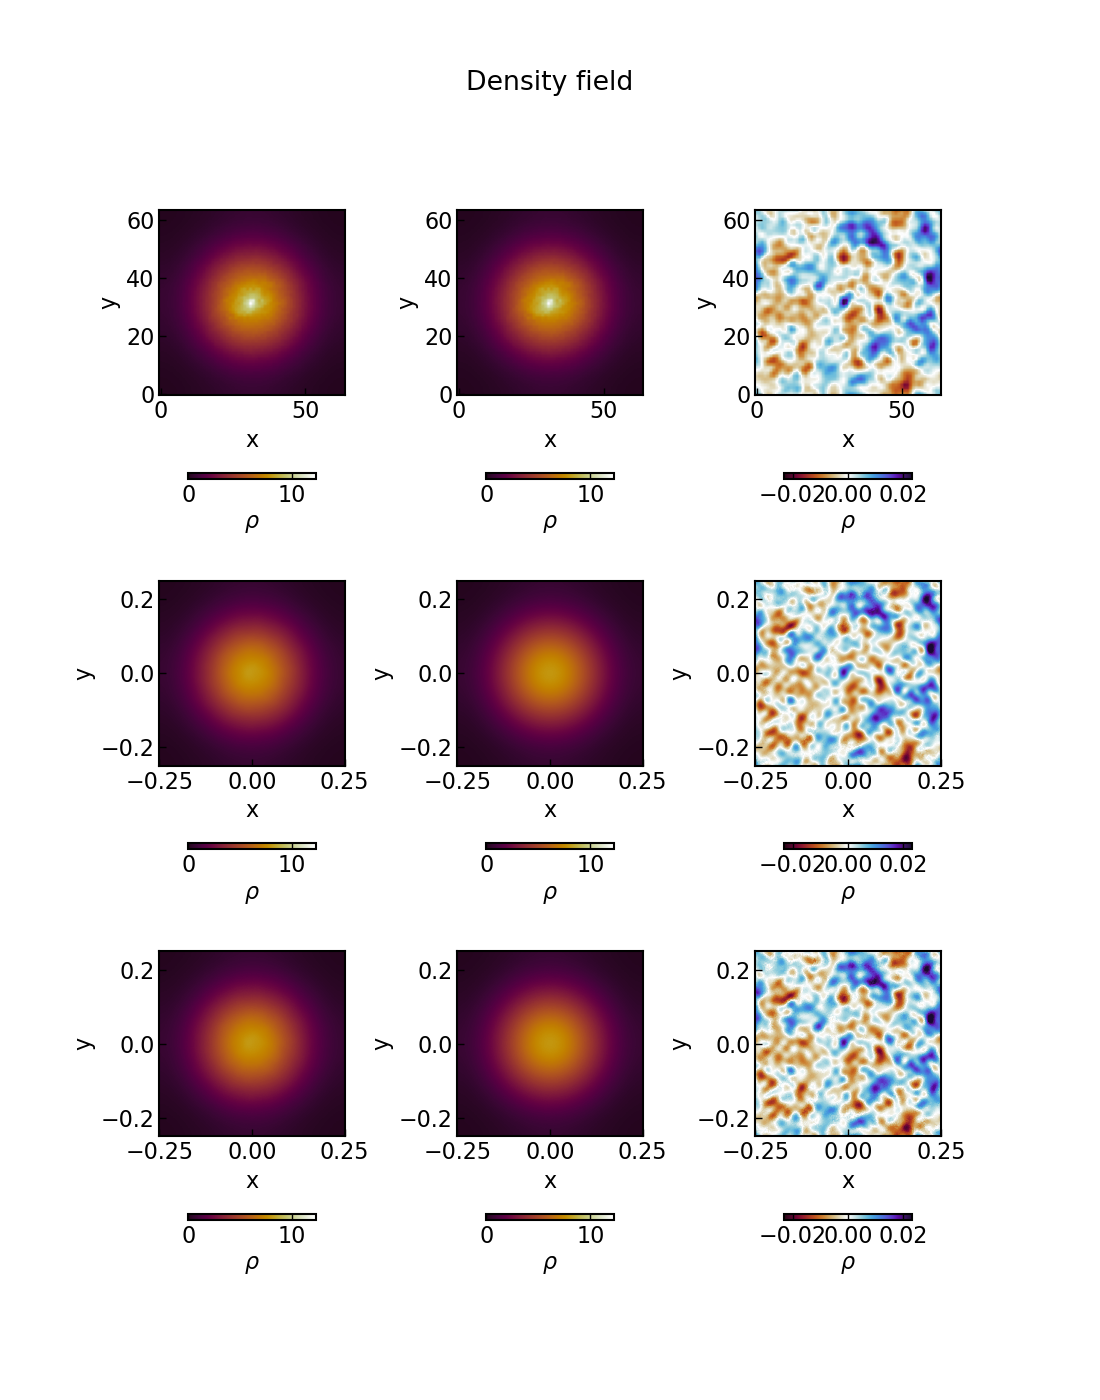

In [22]:
dens_tot = density_total[:,:,int(ngrid//2)-1].T
dens_fluct = density_fluct[:,:,int(ngrid//2)-1].T
dens_back = density_backg[:,:,int(ngrid//2)-1].T

dens_tot_slicer = slicer.slice_variable('0_synthetic_rhofield').value
dens_fluct_slicer = slicer.slice_variable('0_synthetic_fluct').value
dens_back_slicer = slicer.slice_variable('0_synthetic_backg').value

dens_tot = dens_tot.value
dens_fluct = dens_fluct.value
dens_back = dens_back.value

vmax = np.max(np.abs(dens_tot))
vmin = -vmax
norm1 = Normalize(vmin=0.,vmax=vmax)

vmax = np.max(np.abs(dens_fluct))
vmin = -vmax
norm2 = Normalize(vmin=vmin,vmax=vmax)

cmap1 = cmr.fall
cmap2 = cmr.fusion

fig, ax = plt.subplots(3,3,figsize=(11,14))

ims = []

im00 = ax[0,0].imshow(
    dens_tot, origin='lower', norm=norm1, cmap=cmap1)
ims.append(im00)

im01 = ax[0,1].imshow(
    dens_back, origin='lower', norm=norm1, cmap=cmap1)
ims.append(im01)

im02 = ax[0,2].imshow(
    dens_fluct, origin='lower', norm=norm2, cmap=cmap2)
ims.append(im02)

im10 = ax[1,0].imshow(
    dens_tot_slicer, origin='lower', norm=norm1, cmap=cmap1, extent=extent.value)
ims.append(im10)

im11 = ax[1,1].imshow(
    dens_back_slicer, origin='lower', norm=norm1, cmap=cmap1, extent=extent.value)
ims.append(im11)

im12 = ax[1,2].imshow(
    dens_fluct_slicer, origin='lower', norm=norm2, cmap=cmap2, extent=extent.value)
ims.append(im12)

im20 = ax[2,0].imshow(
    dens_total_slicer_depo[:,:,int(npix_small_slicer//2)-1] , 
    origin='lower', norm=norm1, cmap=cmap1, extent=extent.value)
ims.append(im20)

im21 = ax[2,1].imshow(
    dens_backg_slicer_depo[:,:,int(npix_small_slicer//2)-1],
    origin='lower', norm=norm1, cmap=cmap1, extent=extent.value)
ims.append(im21)

im22 = ax[2,2].imshow(
    dens_fluct_slicer_depo[:,:,int(npix_small_slicer//2)-1],
    origin='lower', norm=norm2, cmap=cmap2, extent=extent.value)
ims.append(im22)

for i in range(3):
    for j in range(3):
        ax[i,j].set_xlabel('x')
        ax[i,j].set_ylabel('y')
        el = i*3 + j
        # print(el)
        cbar = fig.colorbar(ims[el], ax=ax[i,j], orientation='horizontal',shrink=0.45, pad=0.25)
        cbar.set_label(r'$\rho$')



fig.subplots_adjust(top=0.85,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.2,
wspace=0.05)

fig.suptitle('Density field',y=0.95)

# plt.savefig('./../../plots/power-spectra/'+savename+'.pdf',dpi=400)


In [23]:
powerspectrrho_backgr, k1d = P1d(amplitudes_rho_backgr, K2, widths) 
powerspectrrho_tot, k1d = P1d(amplitudes_rho_tot, K2, widths) 
powerspectrrho_fluct, k1d = P1d(amplitudes_rho_fluct, K2, widths) 

energy (fourier space) = 3.5483e+08
energy (fourier space) = 3.5487e+08
energy (fourier space) = 1.2501e+08


In [24]:

# # let's apply a mask that zeroes out the central sphere of radius 1e2
# # mask = ~pa.util.get_index_of_radial_range(snap['0_Coordinates'], center, 0.0, 1e2)
# powerspectr_mex, k1d_mex = mhat.compute_spectrum('0_synthetic_rhofield', 
#                                               mask=None, 
#                                              weight=None, optimized=False)

In [25]:
# np.savez("power_spectra_example", true_rhotot=[k1d,powerspectrrho_tot], 
#         true_rhobackg=[k1d, powerspectrrho_backgr],
#         true_rhofluct=[k1d, powerspectrrho_fluct],
#         basic_rhotot=[k1d_basic.value, powerspectr_basic.value],
#         hann_rhotot=[k1d_hann.value, powerspectr_hann.value],
#         mex_rhotot=[k1d_mex.value, powerspectr_mex.value])

In [26]:
npzfile = np.load("power_spectra_example.npz")
k1d_mex, powerspectr_mex = npzfile['mex_rhotot']
k1d_mex *= k1d_basic.unit
powerspectr_mex *= powerspectr_basic.unit

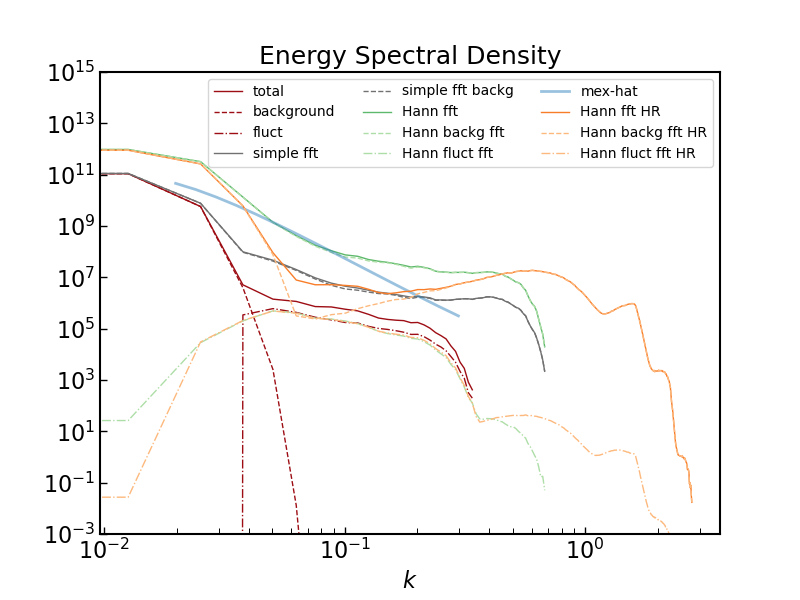

In [27]:
fig, ax = plt.subplots(figsize=(8,6))

tt = np.logspace(np.log10(2e-2), 0, 100)

ax.plot(k1d, powerspectrrho_tot, ls='-', lw=1., color=reds[1],
        markerfacecolor='none', label=r'total')

ax.plot(k1d, powerspectrrho_backgr, ls='--', lw=1., color=reds[1],
        markerfacecolor='none', label=r'background')

ax.plot(k1d, powerspectrrho_fluct, ls='-.', lw=1., color=reds[1],
        markerfacecolor='none', label=r'fluct')

ax.plot(k1d_basic.value, powerspectr_basic.value, ls='-', lw=1., color=grays[4],
        markerfacecolor='none', markersize=4, label=r'simple fft')

ax.plot(k1d_basic.value, powerspectr_backg_basic.value, ls='--', lw=1., color=grays[4],
        markerfacecolor='none', markersize=4, label=r'simple fft backg')

# ax.plot(k1d_padded.value, powerspectr_padded.value, ls='-', color=blues[4],
#         markerfacecolor='none', markersize=4, label=r'padded fft')

ax.plot(k1d_hann.value, powerspectr_hann.value, ls='-', lw=1., color=greens[4],
        markerfacecolor='none', markersize=4, label=r'Hann fft ')

ax.plot(k1d_hann.value, powerspectr_backg_hann.value, ls='--', lw=1., color=greens[6],
        markerfacecolor='none', markersize=4, label=r'Hann backg fft ')

ax.plot(k1d_hann.value, powerspectr_fluct_hann.value, ls='-.', lw=1., color=greens[6],
        markerfacecolor='none', markersize=4, label=r'Hann fluct fft ')

ax.plot(k1d_mex.value, powerspectr_mex.value, ls='-', alpha=0.5,lw=2., color=blues[3],
        markerfacecolor='none', markersize=4, label=r'mex-hat')


# ax.plot(k1d_slicer_hann.value, powerspectr_total_HR_hann.value, ls='-', marker='o', lw=1., color=greens[4],
#         markerfacecolor='none', markersize=4, label=r'Hann fft HR')

# ax.plot(k1d_slicer_hann.value, powerspectr_backg_HR_hann.value, ls='-', marker='o', lw=1., color=greens[6],
#         markerfacecolor='none', markersize=4, label=r'Hann backg fft HR')

# ax.plot(k1d_slicer_hann.value, powerspectr_fluct_HR_hann.value, ls='-', marker='o', lw=1., color=greens[6],
#         markerfacecolor='none', markersize=4, label=r'Hann fluct fft HR')

ax.plot(k1d_slicer_hann.value, powerspectr_total_HR_hann.value, ls='-', lw=1., color=oranges[4],
        markerfacecolor='none', markersize=4, label=r'Hann fft HR')

ax.plot(k1d_slicer_hann.value, powerspectr_backg_HR_hann.value, ls='--', lw=1., color=oranges[6],
        markerfacecolor='none', markersize=4, label=r'Hann backg fft HR')

ax.plot(k1d_slicer_hann.value, powerspectr_fluct_HR_hann.value, ls='-.', lw=1., color=oranges[6],
        markerfacecolor='none', markersize=4, label=r'Hann fluct fft HR')

# ax.plot(k1d_slicer_hann.value, powerspectr_total_slicer_hann.value, ls='-', lw=1., color='k',
#         markerfacecolor='none', markersize=4, label=r'Hann slicer fft ')

# ax.plot(k1d_slicer_hann.value, powerspectr_backg_slicer_hann.value, ls='--', lw=1., color='k',
#         markerfacecolor='none', markersize=4, label=r'Hann slicer backg fft ')

# ax.plot(k1d_slicer_hann.value, powerspectr_fluct_slicer_hann.value, ls='-.', lw=1., color='k',
#         markerfacecolor='none', markersize=4, label=r'Hann slicer fluct fft ')

# ax.plot(tt, 1e10*tt**(-5./3.), ls='-', color='k',lw=1., label=r'$k^{-5/3}$')

ax.set_xlabel('$k$', fontsize=16)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc='best',ncols=3,fontsize=10)

ax.set_title(r'Energy Spectral Density', fontsize=18)

# ax.set_xlim(xmin=1e-2)
ax.set_ylim(ymin=1e-3,ymax=1e15)
# ax.set_ylim(ymin=1e-20)
# ax[1].set_xlim(xmax=30)

plt.savefig('./../../plots/power-spectra/'+'test_different_ffts_backg_fluct'+'.pdf',dpi=400)
# plt.show()


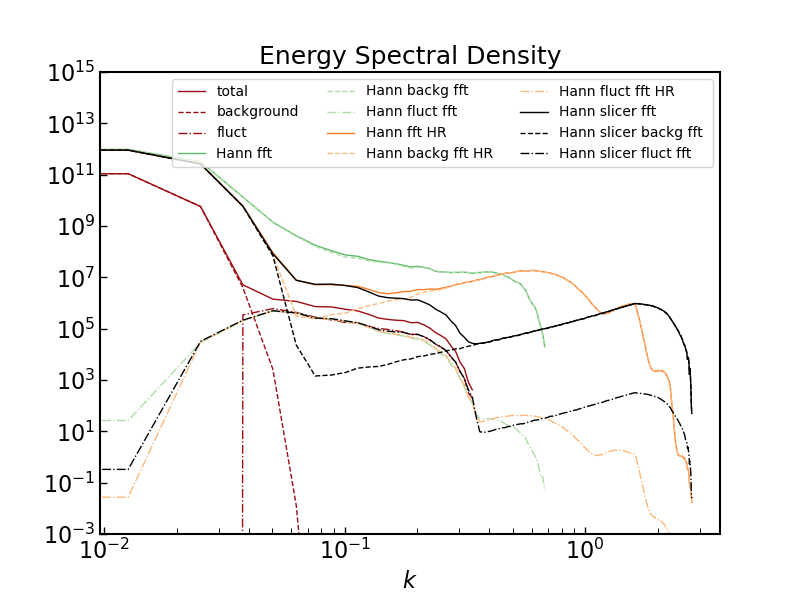

In [28]:
fig, ax = plt.subplots(figsize=(8,6))

tt = np.logspace(np.log10(2e-2), 0, 100)

ax.plot(k1d, powerspectrrho_tot, ls='-', lw=1., color=reds[1],
        markerfacecolor='none', label=r'total')

ax.plot(k1d, powerspectrrho_backgr, ls='--', lw=1., color=reds[1],
        markerfacecolor='none', label=r'background')

ax.plot(k1d, powerspectrrho_fluct, ls='-.', lw=1., color=reds[1],
        markerfacecolor='none', label=r'fluct')

# ax.plot(k1d_basic.value, powerspectr_basic.value, ls='-', color=grays[4],
#         markerfacecolor='none', markersize=4, label=r'simple fft')

# ax.plot(k1d_basic.value, powerspectr_backg_basic.value, ls='--', color=grays[4],
#         markerfacecolor='none', markersize=4, label=r'simple fft backg')

# ax.plot(k1d_padded.value, powerspectr_padded.value, ls='-', color=blues[4],
#         markerfacecolor='none', markersize=4, label=r'padded fft')

ax.plot(k1d_hann.value, powerspectr_hann.value, ls='-', lw=1., color=greens[4],
        markerfacecolor='none', markersize=4, label=r'Hann fft ')

ax.plot(k1d_hann.value, powerspectr_backg_hann.value, ls='--', lw=1., color=greens[6],
        markerfacecolor='none', markersize=4, label=r'Hann backg fft ')

ax.plot(k1d_hann.value, powerspectr_fluct_hann.value, ls='-.', lw=1., color=greens[6],
        markerfacecolor='none', markersize=4, label=r'Hann fluct fft ')

# ax.plot(k1d_mex.value, powerspectr_mex.value, ls='--', color=grays[7],
#         markerfacecolor='none', markersize=4, label=r'mex-hat')


ax.plot(k1d_slicer_hann.value, powerspectr_total_HR_hann.value, ls='-', lw=1., color=oranges[4],
        markerfacecolor='none', markersize=4, label=r'Hann fft HR')

ax.plot(k1d_slicer_hann.value, powerspectr_backg_HR_hann.value, ls='--', lw=1., color=oranges[6],
        markerfacecolor='none', markersize=4, label=r'Hann backg fft HR')

ax.plot(k1d_slicer_hann.value, powerspectr_fluct_HR_hann.value, ls='-.', lw=1., color=oranges[6],
        markerfacecolor='none', markersize=4, label=r'Hann fluct fft HR')


ax.plot(k1d_slicer_hann.value, powerspectr_total_slicer_hann.value, ls='-', lw=1., color='k',
        markerfacecolor='none', markersize=4, label=r'Hann slicer fft ')

ax.plot(k1d_slicer_hann.value, powerspectr_backg_slicer_hann.value, ls='--', lw=1., color='k',
        markerfacecolor='none', markersize=4, label=r'Hann slicer backg fft ')

ax.plot(k1d_slicer_hann.value, powerspectr_fluct_slicer_hann.value, ls='-.', lw=1., color='k',
        markerfacecolor='none', markersize=4, label=r'Hann slicer fluct fft ')

# ax.plot(tt, 1e10*tt**(-5./3.), ls='-', color='k',lw=1., label=r'$k^{-5/3}$')

ax.set_xlabel('$k$', fontsize=16)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc='best',ncols=3,fontsize=10)

ax.set_title(r'Energy Spectral Density', fontsize=18)

# ax.set_xlim(xmin=1e-2)
ax.set_ylim(ymin=1e-3,ymax=1e15)
# ax.set_ylim(ymin=1e-20)
# ax[1].set_xlim(xmax=30)

plt.savefig('./../../plots/power-spectra/'+'test_different_ffts_backg_fluct_Hann'+'.pdf',dpi=400)
# plt.show()


In [38]:
k_cut = 1./(widths[0]/20)
filter_length = np.sqrt(2)*(1./k_cut)*np.ones(snap['0_Diameters'].shape)*arepo_length

sf = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=None, 
                        search_radius=filter_length.value)

smooth_density_tot, turb_density_tot = tc.extract_turbulent_scalar(snap, sf, '0_synthetic_rhofield', filter_length, 
                                               weight=None, test_type=None, 
                                               filter_type="gaussian", 
                                               iterative=False, optimized=True)

relative_density = np.zeros(smooth_density_tot.shape)*(snap['0_Density'][0]/density_unit).uq
relative_density[sf.index] = (turb_density_tot[sf.index]/snap['0_synthetic_rhofield'][sf.index])


min/max/avg occupancy cartesian tiling 0 / 43 / 4.04


In [42]:
# k_cut = 1./(widths[0]/20)

In [39]:


with tc.DepositCartesianGrid(snap, center, widths, npoints=npix_small_slicer, 
                           threadsperblock=256, 
                           regionType='cartesian', kernel_type="PCS") as depo_slicer:
        
    filt_relative_density_depo = depo_slicer.deposit_variable(relative_density, weight='0_Volume')
    filt_turb_density_depo = depo_slicer.deposit_variable(turb_density_tot, weight='0_Volume')
    filt_smooth_density_depo = depo_slicer.deposit_variable(smooth_density_tot, weight='0_Volume')
    
    # with windowing
    powerspectr_filt_rel_den_hann, k1d_slicer_hann, _ = depo_slicer.power_spectrum1d(filt_relative_density_depo*density_unit,
                                                              window=scipy.signal.windows.hann)
    powerspectr_filt_turb_den_hann, k1d_slicer_hann, _ = depo_slicer.power_spectrum1d(filt_turb_density_depo,
                                                              window=scipy.signal.windows.hann)
    powerspectr_filt_smooth_den_hann, k1d_slicer_hann, _ = depo_slicer.power_spectrum1d(filt_smooth_density_depo,
                                                              window=scipy.signal.windows.hann)

energy (real space) = 1.4507e+07
energy (fourier space) = 1.3697e+06
energy (real space) = 4.2611e+06
energy (fourier space) = 4.3066e+07
energy (real space) = 2.9758e+08
energy (fourier space) = 2.0613e+09
bye


Text(0.5, 0.95, 'Density field')

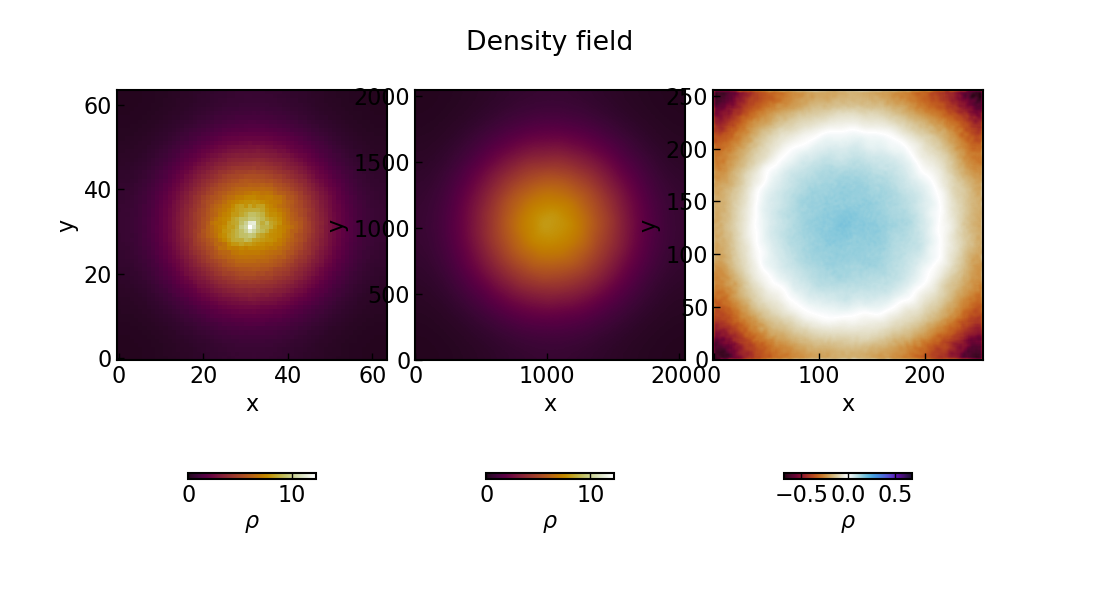

In [40]:
# dens_tot = density_total[:,:,int(ngrid//2)-1].T
# dens_fluct = density_fluct[:,:,int(ngrid//2)-1].T
# dens_back = density_backg[:,:,int(ngrid//2)-1].T

dens_tot_filt = filt_relative_density_depo[:,:,int(npix_small_slicer//2)-1].T
dens_tot_filt = dens_tot_filt.value
# dens_tot_slicer = slicer.slice_variable('0_synthetic_rhofield').value
# dens_fluct_slicer = slicer.slice_variable('0_synthetic_fluct').value
# dens_back_slicer = slicer.slice_variable('0_synthetic_backg').value

# dens_tot = dens_tot.value
# dens_fluct = dens_fluct.value
# dens_back = dens_back.value

vmax = np.max(np.abs(dens_tot))
vmin = -vmax
norm1 = Normalize(vmin=0.,vmax=vmax)

vmax = np.max(np.abs(dens_tot_filt))
vmin = -vmax
norm2 = Normalize(vmin=vmin,vmax=vmax)

cmap1 = cmr.fall
cmap2 = cmr.fusion

fig, ax = plt.subplots(1,3,figsize=(11,6))

ims = []

im00 = ax[0].imshow(
    dens_tot, origin='lower', norm=norm1, cmap=cmap1)
ims.append(im00)

im01 = ax[1].imshow(
    dens_tot_slicer, origin='lower', norm=norm1, cmap=cmap1)
ims.append(im01)

im02 = ax[2].imshow(
    dens_tot_filt, origin='lower', norm=norm2, cmap=cmap2)
ims.append(im02)


# for i in range(3):
for j in range(3):
    ax[j].set_xlabel('x')
    ax[j].set_ylabel('y')
    el = j
    # print(el)
    cbar = fig.colorbar(ims[el], ax=ax[j], orientation='horizontal',shrink=0.45, pad=0.25)
    cbar.set_label(r'$\rho$')



fig.subplots_adjust(top=0.85,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.2,
wspace=0.05)

fig.suptitle('Density field',y=0.95)

# plt.savefig('./../../plots/power-spectra/'+savename+'.pdf',dpi=400)


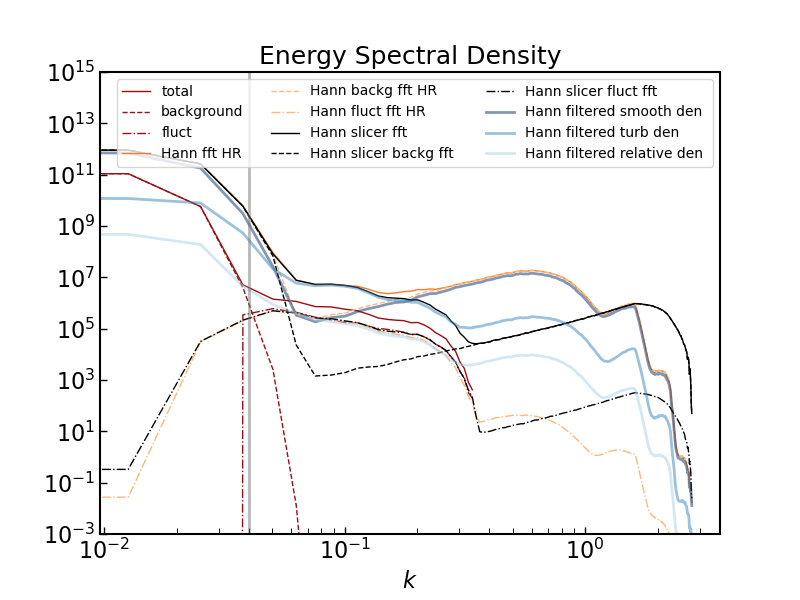

In [43]:
fig, ax = plt.subplots(figsize=(8,6))

tt = np.logspace(np.log10(2e-2), 0, 100)

ax.plot(k1d, powerspectrrho_tot, ls='-', lw=1., color=reds[1],
        markerfacecolor='none', label=r'total')

ax.plot(k1d, powerspectrrho_backgr, ls='--', lw=1., color=reds[1],
        markerfacecolor='none', label=r'background')

ax.plot(k1d, powerspectrrho_fluct, ls='-.', lw=1., color=reds[1],
        markerfacecolor='none', label=r'fluct')

# ax.plot(k1d_basic.value, powerspectr_basic.value, ls='-', color=grays[4],
#         markerfacecolor='none', markersize=4, label=r'simple fft')

# ax.plot(k1d_basic.value, powerspectr_backg_basic.value, ls='--', color=grays[4],
#         markerfacecolor='none', markersize=4, label=r'simple fft backg')

# ax.plot(k1d_padded.value, powerspectr_padded.value, ls='-', color=blues[4],
#         markerfacecolor='none', markersize=4, label=r'padded fft')

# ax.plot(k1d_hann.value, powerspectr_hann.value, ls='-', lw=1., color=greens[4],
#         markerfacecolor='none', markersize=4, label=r'Hann fft ')

# ax.plot(k1d_hann.value, powerspectr_backg_hann.value, ls='--', lw=1., color=greens[6],
#         markerfacecolor='none', markersize=4, label=r'Hann backg fft ')

# ax.plot(k1d_hann.value, powerspectr_fluct_hann.value, ls='-.', lw=1., color=greens[6],
#         markerfacecolor='none', markersize=4, label=r'Hann fluct fft ')

# ax.plot(k1d_mex.value, powerspectr_mex.value, ls='--', color=grays[7],
#         markerfacecolor='none', markersize=4, label=r'mex-hat')


ax.plot(k1d_slicer_hann.value, powerspectr_total_HR_hann.value, ls='-', lw=1., color=oranges[4],
        markerfacecolor='none', markersize=4, label=r'Hann fft HR')

ax.plot(k1d_slicer_hann.value, powerspectr_backg_HR_hann.value, ls='--', lw=1., color=oranges[6],
        markerfacecolor='none', markersize=4, label=r'Hann backg fft HR')

ax.plot(k1d_slicer_hann.value, powerspectr_fluct_HR_hann.value, ls='-.', lw=1., color=oranges[6],
        markerfacecolor='none', markersize=4, label=r'Hann fluct fft HR')


ax.plot(k1d_slicer_hann.value, powerspectr_total_slicer_hann.value, ls='-', lw=1., color='k',
        markerfacecolor='none', markersize=4, label=r'Hann slicer fft ')

ax.plot(k1d_slicer_hann.value, powerspectr_backg_slicer_hann.value, ls='--', lw=1., color='k',
        markerfacecolor='none', markersize=4, label=r'Hann slicer backg fft ')

ax.plot(k1d_slicer_hann.value, powerspectr_fluct_slicer_hann.value, ls='-.', lw=1., color='k',
        markerfacecolor='none', markersize=4, label=r'Hann slicer fluct fft ')


ax.plot(k1d_slicer_hann.value, powerspectr_filt_smooth_den_hann.value, ls='-', lw=2., alpha=0.5, color=blues[0],
        markerfacecolor='none', markersize=4, label=r'Hann filtered smooth den ')

ax.plot(k1d_slicer_hann.value, powerspectr_filt_turb_den_hann.value, ls='-', lw=2., alpha=0.5, color=blues[3],
        markerfacecolor='none', markersize=4, label=r'Hann filtered turb den ')

ax.plot(k1d_slicer_hann.value, powerspectr_filt_rel_den_hann.value, ls='-', lw=2., alpha=0.5, color=blues[6],
        markerfacecolor='none', markersize=4, label=r'Hann filtered relative den ')

ax.vlines(k_cut, ymin=1e-3,ymax=1e15, color=grays[4], alpha=0.5, lw=2)


# ax.plot(tt, 1e10*tt**(-5./3.), ls='-', color='k',lw=1., label=r'$k^{-5/3}$')

ax.set_xlabel('$k$', fontsize=16)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc='best',ncols=3,fontsize=10)

ax.set_title(r'Energy Spectral Density', fontsize=18)

# ax.set_xlim(xmin=1e-2)
ax.set_ylim(ymin=1e-3,ymax=1e15)
# ax.set_ylim(ymin=1e-20)
# ax[1].set_xlim(xmax=30)

plt.savefig('./../../plots/power-spectra/'+'test_different_ffts_backg_fluct_Hann_filtered'+'.pdf',dpi=400)
# plt.show()


In [47]:
if 'abcd' in snap.keys():
    print('yes')
else:
    print('no')

no


In [49]:
'0_Masses' in snap.keys()

True

In [50]:
'0_Density' and '0_Masses' in snap.keys()

True

In [51]:
'0_Density' and 'abcd' in snap.keys()

False